In [34]:
# Load Smarket and Caravan datasets from ISLP library
from ISLP import load_data
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score

Smarket = load_data('Smarket')
Caravan = load_data('Caravan')

print("Smarket dataset")
print("Shape:", Smarket.shape)
print("First 5 rows:")
print(Smarket.head(5))

print("\nCaravan dataset")
print("Shape:", Caravan.shape)
print("First 5 rows:")
print(Caravan.head(5))




Smarket dataset
Shape: (1250, 9)
First 5 rows:
   Year   Lag1   Lag2   Lag3   Lag4   Lag5  Volume  Today Direction
0  2001  0.381 -0.192 -2.624 -1.055  5.010  1.1913  0.959        Up
1  2001  0.959  0.381 -0.192 -2.624 -1.055  1.2965  1.032        Up
2  2001  1.032  0.959  0.381 -0.192 -2.624  1.4112 -0.623      Down
3  2001 -0.623  1.032  0.959  0.381 -0.192  1.2760  0.614        Up
4  2001  0.614 -0.623  1.032  0.959  0.381  1.2057  0.213        Up

Caravan dataset
Shape: (5822, 86)
First 5 rows:
   MOSTYPE  MAANTHUI  MGEMOMV  MGEMLEEF  MOSHOOFD  MGODRK  MGODPR  MGODOV  \
0       33         1        3         2         8       0       5       1   
1       37         1        2         2         8       1       4       1   
2       37         1        2         2         8       0       4       2   
3        9         1        3         3         3       2       3       2   
4       40         1        4         2        10       1       4       1   

   MGODGE  MRELGE  ...  APERSONG 

In [35]:
# Train/test split for Smarket dataset
import statsmodels.api as sm

# Features (all numeric predictors)
X = Smarket[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
y = Smarket['Direction'].map({'Up':1, 'Down':0})

# Quick check of response balance
print("Direction value counts:")
print(y.value_counts())

# Train/test split using year
train_id = (Smarket['Year'] < 2005)
test_id  = (Smarket['Year'] == 2005)

X_train, X_test = X.loc[train_id], X.loc[test_id]
y_train, y_test = y.loc[train_id], y.loc[test_id]

# Add intercept (statsmodels does not add automatically)
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)



Direction value counts:
Direction
1    648
0    602
Name: count, dtype: int64
Train shape: (998, 7)  Test shape: (252, 7)


Coefficient estimates (training data):
        Estimate  Std. Error  z value  p value
const      0.191       0.334    0.573    0.567
Lag1      -0.054       0.052   -1.046    0.295
Lag2      -0.046       0.052   -0.884    0.377
Lag3       0.007       0.052    0.139    0.889
Lag4       0.006       0.052    0.125    0.901
Lag5      -0.004       0.051   -0.083    0.934
Volume    -0.116       0.240   -0.485    0.628
Confusion matrix:
             Predicted Down  Predicted Up
Actual Down              77            97
Actual Up                34            44

Test accuracy: 0.48


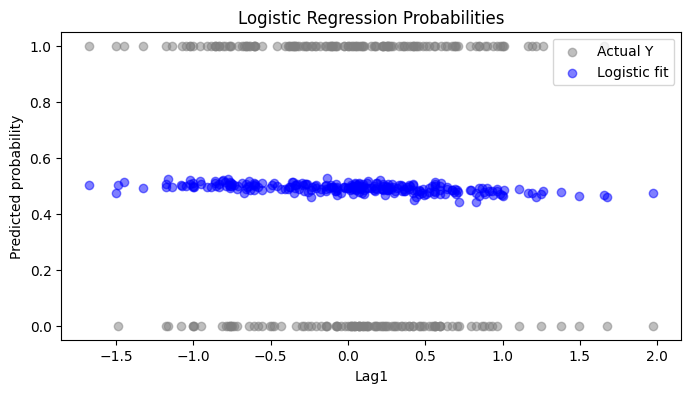

In [ ]:
# Baseline logistic regression (all predictors)
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


# Fit logistic regression using GLM with binomial family
glm_model = sm.GLM(y_train, X_train, family=sm.families.Binomial()).fit()

# Compact coefficient table
coef_table = pd.DataFrame({
    "Estimate": glm_model.params,
    "Std. Error": glm_model.bse,
    "z value": glm_model.tvalues,
    "p value": glm_model.pvalues
})
print("Coefficient estimates (training data):")
print(coef_table.round(3))

# Predictions on test set
y_pred_prob = glm_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate
# Confusion matrix (rows=predicted, cols=actual)
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm.T,   # transpose to flip into ISLP style
                     index=['Actual Down', 'Actual Up'], 
                     columns=['Predicted Down', 'Predicted Up'])

print("Confusion matrix:")
print(cm_df)

print("\nTest accuracy:", round(accuracy_score(y_test, y_pred),3))



# Plot predicted probabilities vs Lag1
plt.figure(figsize=(8,4))
plt.scatter(X_test['Lag1'], y_test, color='gray', alpha=0.5, label='Actual Y')
plt.scatter(X_test['Lag1'], y_pred_prob, color='blue', alpha=0.5, label='Logistic fit')
plt.xlabel('Lag1')
plt.ylabel('Predicted probability')
plt.title('Logistic Regression Probabilities')
plt.legend()
plt.show()


In [13]:
# Predictors: Lag1 and Lag2 only
X12 = Smarket[['Lag1', 'Lag2']]
X12_train, X12_test = X12.loc[train_id], X12.loc[test_id]

# Add intercept
X12_train = sm.add_constant(X12_train)
X12_test  = sm.add_constant(X12_test)

# Fit logistic regression
glm_model_12 = sm.GLM(y_train, X12_train, family=sm.families.Binomial()).fit()

# Compact coefficient table
coef_table_12 = pd.DataFrame({
    "Estimate": glm_model_12.params,
    "Std. Error": glm_model_12.bse,
    "z value": glm_model_12.tvalues,
    "p value": glm_model_12.pvalues
})
print("Coefficient estimates (training data):")
print(coef_table_12.round(3))

# Predictions on test set
y_pred_prob_12 = glm_model_12.predict(X12_test)
y_pred_12 = (y_pred_prob_12 > 0.5).astype(int)

# Confusion matrix (ISLP style)
cm_12 = confusion_matrix(y_test, y_pred_12)
cm_df_12 = pd.DataFrame(cm_12.T,  # transpose for ISLP style
                        index=['Actual Down', 'Actual Up'],
                        columns=['Predicted Down', 'Predicted Up'])
print("\nConfusion matrix:")
print(cm_df_12)

# Test accuracy
print("\nTest accuracy (Lag1+Lag2):", round(accuracy_score(y_test, y_pred_12),3))


Coefficient estimates (training data):
       Estimate  Std. Error  z value  p value
const     0.032       0.063    0.508    0.611
Lag1     -0.056       0.052   -1.076    0.282
Lag2     -0.044       0.052   -0.861    0.389

Confusion matrix:
             Predicted Down  Predicted Up
Actual Down              35            35
Actual Up                76           106

Test accuracy (Lag1+Lag2): 0.56


Coefficient estimates (training data):
          Estimate  Std. Error  z value  p value
const      397.634  831837.451    0.000    1.000
MOSTYPE      0.070       0.060    1.168    0.243
MAANTHUI    -0.264       0.269   -0.984    0.325
MGEMOMV      0.157       0.180    0.869    0.385
MGEMLEEF     0.133       0.133    0.996    0.319
MOSHOOFD    -0.277       0.271   -1.023    0.306
MGODRK      -0.190       0.141   -1.351    0.177
MGODPR      -0.094       0.155   -0.609    0.542
MGODOV      -0.046       0.137   -0.335    0.738
MGODGE      -0.097       0.146   -0.667    0.505
Confusion matrix (threshold 0.5):
               Actual No  Actual Yes
Predicted No        2180         136
Predicted Yes         10           3

Accuracy: 0.937  Precision: 0.231  Recall: 0.022
Confusion matrix (threshold 0.25):
               Actual No  Actual Yes
Predicted No        2145         122
Predicted Yes         45          17

Accuracy: 0.928, Precision: 0.274, Recall: 0.122


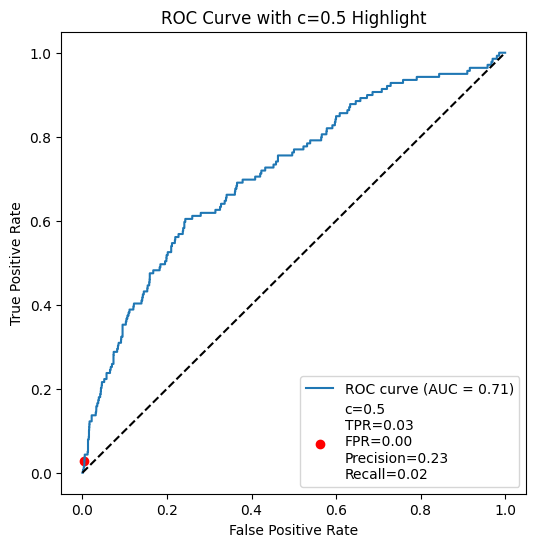

In [33]:
# Load dataset
from ISLP import load_data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc
import statsmodels.api as sm
import matplotlib.pyplot as plt

Caravan = load_data('Caravan')

# Separate predictors and response
X = Caravan.drop(columns='Purchase')
y = Caravan['Purchase'].map({'Yes':1, 'No':0})

# Train/test split (e.g., 60/40)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Add intercept
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

# Logistic regression
glm_caravan = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial()).fit()

# Compact coefficient table
coef_table = pd.DataFrame({
    "Estimate": glm_caravan.params,
    "Std. Error": glm_caravan.bse,
    "z value": glm_caravan.tvalues,
    "p value": glm_caravan.pvalues
})
print("Coefficient estimates (training data):")
print(coef_table.head(10).round(3))  # show first 10

# Predict probabilities on test set
y_pred_prob = glm_caravan.predict(X_test_sm)

# Default threshold 0.5
y_pred_05 = (y_pred_prob > 0.5).astype(int)

# Confusion matrix ISLP-style
cm = confusion_matrix(y_test, y_pred_05)
cm_df = pd.DataFrame(cm.T, 
                     index=['Predicted No', 'Predicted Yes'],
                     columns=['Actual No', 'Actual Yes'])

print("Confusion matrix (threshold 0.5):")
print(cm_df)


acc = accuracy_score(y_test, y_pred_05)
prec = precision_score(y_test, y_pred_05)
rec = recall_score(y_test, y_pred_05)
print("\nAccuracy:", round(acc,3), " Precision:", round(prec,3), " Recall:", round(rec,3))

# Alternative threshold
y_pred_25 = (y_pred_prob > 0.25).astype(int)
cm = confusion_matrix(y_test, y_pred_25)
cm_df = pd.DataFrame(cm.T, 
                     index=['Predicted No', 'Predicted Yes'],
                     columns=['Actual No', 'Actual Yes'])
print("Confusion matrix (threshold 0.25):")
print(cm_df)


# Metrics
acc = accuracy_score(y_test, y_pred_25)
prec = precision_score(y_test, y_pred_25)
rec = recall_score(y_test, y_pred_25)

print(f"\nAccuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}")


# y_test and y_pred_prob are from logistic regression
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Find index for threshold closest to 0.5
idx = (np.abs(thresholds - 0.5)).argmin()
fpr_05 = fpr[idx]
tpr_05 = tpr[idx]
precision_05 = precision_score(y_test, (y_pred_prob > 0.5).astype(int))
recall_05 = recall_score(y_test, (y_pred_prob > 0.5).astype(int))

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.scatter(fpr_05, tpr_05, color='red', label=f'c=0.5\nTPR={tpr_05:.2f}\nFPR={fpr_05:.2f}\nPrecision={precision_05:.2f}\nRecall={recall_05:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with c=0.5 Highlight')
plt.legend(loc='lower right')
plt.show()


